In [4]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

plt.style.use("ggplot")


In [5]:
df = pd.read_csv("../data/processed/cleaned_comments.csv")

vectorizer = joblib.load("../models/vectorizer.pkl")
model = joblib.load("../models/toxic_model.pkl")



In [7]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42
)

X_test = vectorizer.transform(test_df["cleaned_text"])
y_test = test_df["is_toxic"]


In [8]:
y_pred = model.predict(X_test)


y_proba = model.predict_proba(X_test)[:, 1]


In [9]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     28631
           1       0.94      0.63      0.75      3266

    accuracy                           0.96     31897
   macro avg       0.95      0.81      0.86     31897
weighted avg       0.96      0.96      0.95     31897



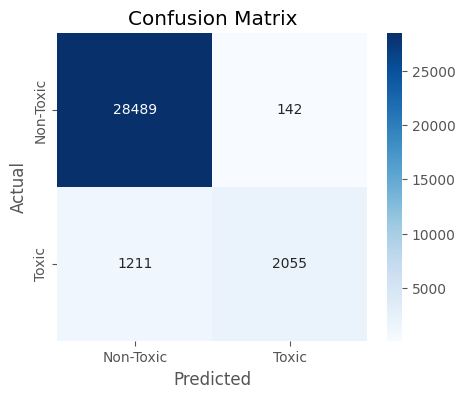

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Toxic", "Toxic"],
            yticklabels=["Non-Toxic", "Toxic"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


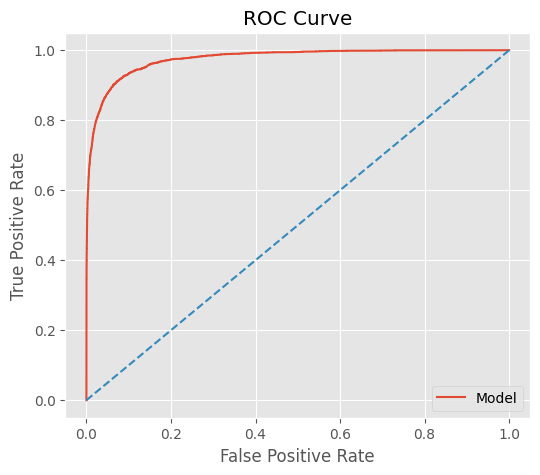

In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Model")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [12]:
auc_score = roc_auc_score(y_test, y_proba)
print("AUC Score:", auc_score)


AUC Score: 0.9755999341495457


In [13]:
test_df["predicted"] = y_pred

misclassified = test_df[test_df["is_toxic"] != test_df["predicted"]]

misclassified[["comment_text", "is_toxic", "predicted"]].head(10)


,comment_text,is_toxic,predicted
98345,Someone is threatning an annon and that is unc...,1,0
79734,"HEY, ITS JUST MAH TALK PAGE \r\n\r\nThat's all...",1,0
132853,"no the gc's are directly relevant, israel was ...",1,0
80797,"He was a racial Jew, you fool. If you want to ...",1,0
41438,'m personally attacking you. Racism. It makes ...,1,0
156568,"""\r\n\r\n""""The war is over. And you lost."""" No...",1,0
41028,UNBLOCK SHANNON! \r\n UNBLOCK SHANNON! \r\n UN...,1,0
201,Your blatant POV pushing \r\n\r\nNeither of yo...,1,0
94438,Maybe you're right. Barneca is a really mean a...,0,1
59879,Your vandalism. \r\n\r\nReverting my rational ...,1,0
